# Model Inference

## Objective

The objective of this notebook is to demonstrate the inference capabilities of the trained YOLOv8n model.

Inference refers to using a trained model to detect objects in previously unseen images.

This notebook covers:

- Loading the trained model
- Running inference on new images
- Visualizing predictions
- Adjusting confidence thresholds
- Saving prediction results
- Observing model behavior on different scenes

## Import Required Libraries

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

## Load the Trained YOLOv8 Model

The trained model weights stored in `best.pt` are loaded for performing object detection on unseen images.

In [15]:
MODEL_PATH = "../models/best.pt"

model = YOLO(MODEL_PATH)

print("Model Loaded Successfully!")

Model Loaded Successfully!


# Inference on a Single Image

The trained model is first evaluated on a single unseen image.

The output includes:

- Bounding boxes
- Predicted class labels
- Confidence scores

In [16]:
IMAGE_PATH = "../Data/yolo_dataset/test/images/00000008.jpg"

results = model.predict(
    source=IMAGE_PATH,
    conf=0.25,
    save=True
)


image 1/1 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000008.jpg: 448x640 1 pickup_truck, 88.1ms
Speed: 1.7ms preprocess, 88.1ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /voc/work/Capstone1/notebooks/runs/detect/predict-2


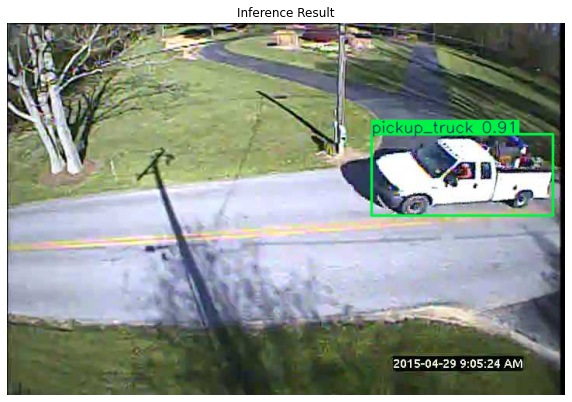

In [17]:
prediction = results[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(prediction[..., ::-1])  # Convert BGR to RGB
plt.axis("off")
plt.title("Inference Result")
plt.show()

## Observation

The detector successfully identifies vehicle as a pickup truck in the unseen image.

The detected object is represented by:

- A bounding box
- Predicted class label
- Confidence score

The confidence score indicates how certain the model is about each prediction.

# Batch Inference

The model can perform inference on multiple images simultaneously.

This demonstrates the scalability of the trained detector.

In [18]:
TEST_FOLDER="../Data/yolo_dataset/test/images"

results = model.predict(
    source=TEST_FOLDER,
    conf=0.25,
    save=True
)


image 1/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000008.jpg: 448x640 1 pickup_truck, 38.1ms
image 2/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000015.jpg: 448x640 2 cars, 1 motorized_vehicle, 1 pickup_truck, 1 work_van, 109.8ms
image 3/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000017.jpg: 448x640 1 car, 1 motorized_vehicle, 93.5ms
image 4/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000029.jpg: 448x640 3 cars, 93.6ms
image 5/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000030.jpg: 448x640 2 cars, 142.1ms
image 6/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000033.jpg: 448x640 1 pickup_truck, 93.4ms
image 7/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000037.jpg: 448x640 2 pickup_trucks, 94.1ms
image 8/563 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000043.jpg: 448x640 1 bus, 27 cars, 2 work

YOLO automatically processes each image and saves the predicted outputs in the `runs/detect/predict` directory.

These outputs include bounding boxes, class labels, and confidence scores for every detected object.

# Effect of Confidence Threshold

The confidence threshold determines the minimum confidence required for a prediction to be displayed.

Lower confidence thresholds detect more objects but may introduce additional false positives.

Higher confidence thresholds reduce false detections but may miss genuine objects.

In [19]:
thresholds = [0.25, 0.50, 0.75]

for conf in thresholds:
    print(f"\nRunning inference with confidence threshold = {conf}")

    model.predict(
        source=IMAGE_PATH,
        conf=conf,
        save=True,
        name=f"conf_{conf}",
        exist_ok=True
    )


Running inference with confidence threshold = 0.25

image 1/1 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000008.jpg: 448x640 1 pickup_truck, 88.5ms
Speed: 1.5ms preprocess, 88.5ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /voc/work/Capstone1/notebooks/runs/detect/conf_0.25

Running inference with confidence threshold = 0.5

image 1/1 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000008.jpg: 448x640 1 pickup_truck, 96.5ms
Speed: 1.5ms preprocess, 96.5ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /voc/work/Capstone1/notebooks/runs/detect/conf_0.5

Running inference with confidence threshold = 0.75

image 1/1 /voc/work/Capstone1/notebooks/../Data/yolo_dataset/test/images/00000008.jpg: 448x640 1 pickup_truck, 133.7ms
Speed: 1.5ms preprocess, 133.7ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /voc/work/Capstone1/notebooks/runs/detect

## Interpretation

As the confidence threshold increases:

- Precision generally improves.
- Recall decreases.
- Fewer objects are detected.
- The model becomes more conservative in making predictions.

Selecting an appropriate confidence threshold depends on the intended application.

For autonomous driving, missing important objects can be more critical than producing occasional false detections.

# Non-Maximum Suppression (NMS)

YOLO may initially generate multiple overlapping bounding boxes for the same object.

Non-Maximum Suppression (NMS) removes redundant detections by retaining only the bounding box with the highest confidence score.

This produces cleaner and more accurate predictions.

# Conclusion

This notebook demonstrated inference using the trained YOLOv8n model on previously unseen images.

The detector successfully localized and classified multiple vehicle categories while maintaining reasonable confidence scores.

The inference results validate that the trained model generalizes effectively beyond the training dataset and can serve as a baseline solution for autonomous driving object detection tasks.# Applications

The trained YOLOv8n detector has potential applications in:

- Autonomous driving
- Traffic monitoring
- Smart city surveillance
- Vehicle counting
- Intelligent transportation systems
- Road safety analytics

Its lightweight architecture also makes it suitable for real-time deployment on edge devices.